In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_pickle('dataframe/fid_stat_ising_default_n26-1.pkl')
df2 = pd.read_pickle('dataframe/fid_stat_ising_default_n26-2.pkl')

df_U = pd.concat((df1, df2))

df1 = pd.read_pickle('dataframe/fid_stat_ising_trotter_n28-1.pkl')
df2 = pd.read_pickle('dataframe/fid_stat_ising_trotter_n28-2.pkl')

df_H = pd.concat((df1, df2))

In [3]:
t_test = np.linspace(0, 1, 101)
loss_type = ['1', '12']
loss_type_line = ['-', 'dotted']

delta_t = [0.1, 0.25, 0.5, 1.0]
color_dt = ['red', 'blue', 'green', 'gold']

def f_data(N, loss_type, delta_t, df):
    return df[(df["N"] == N) & (df["loss_type"] == loss_type) & (np.round(df['delta_t'], decimals=3) == delta_t)]["F"].mean()

def std_data(N, loss_type, delta_t, df):
    sub = df[(df["N"] == N) & (df["loss_type"] == loss_type) & (np.round(df['delta_t'], decimals=3) == delta_t)]["F"]
    return np.std(np.stack(sub.values), axis=0)

def mean_data(N, loss_type, delta_t, df):
    arr = df[(df["N"] == N) & (df["loss_type"] == loss_type) & (np.round(df['delta_t'], decimals=3) == delta_t)]["F"].mean()

    return np.mean(arr), np.std(arr)

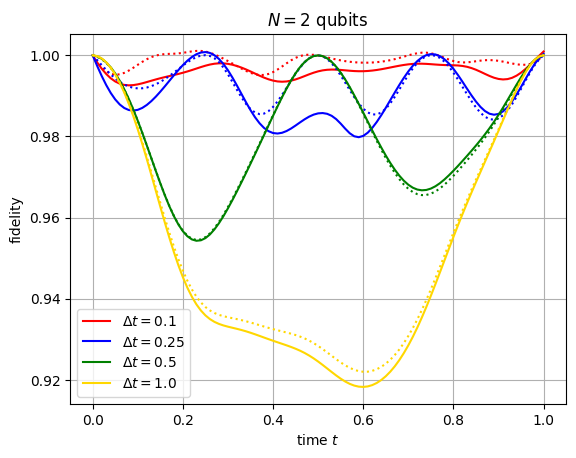

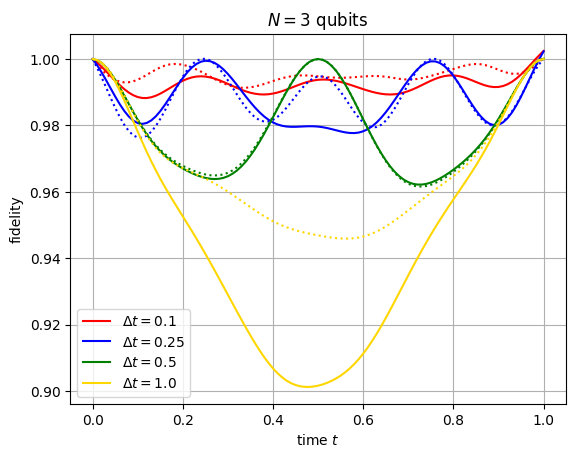

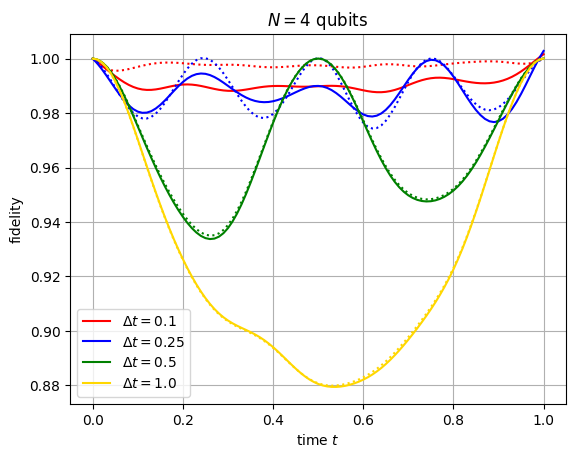

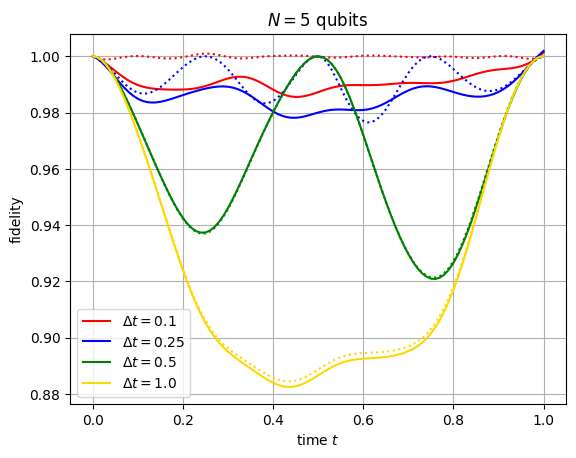

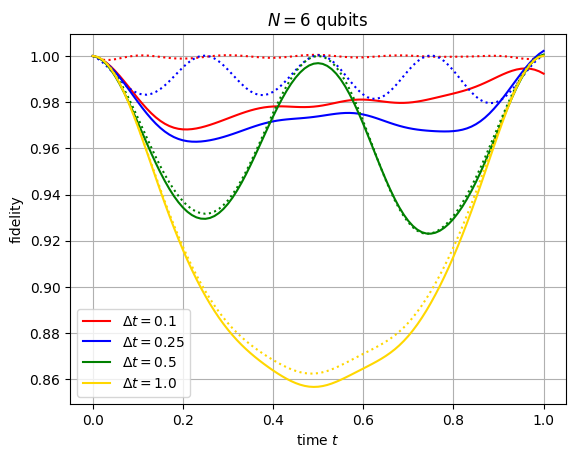

In [4]:
for N in list(set(df_U["N"])):
    for dt, color_dt_ in zip(delta_t, color_dt):
        m1 = f_data(N=N, loss_type='1', delta_t=dt, df=df_U)
        s1 = std_data(N=N, loss_type='1', delta_t=dt, df=df_U)
        m12 = f_data(N=N, loss_type='12', delta_t=dt, df=df_U)
        s12 = std_data(N=N, loss_type='12', delta_t=dt, df=df_U)

        plt.plot(t_test, m1, color=color_dt_, linestyle='-', label=r'$\Delta t = $'+str(dt))
        # plt.fill_between(t_test, m1 - s1, m1 + s1, color=color_dt_, alpha=0.15, linewidth=0)
        plt.plot(t_test, m12, color=color_dt_, linestyle='dotted')
        # plt.fill_between(t_test, m12 - s12, m12 + s12, color=color_dt_, alpha=0.15, linewidth=0)


    plt.grid()
    plt.legend(loc=0)
    # plt.ylim(0.98, 1.005)
    plt.xlabel(r'time $t$')
    plt.ylabel(r'fidelity')
    plt.title(r"$N=$" + str(N) + " qubits")

    plt.show()

In [5]:
print("------------------------ just states ------------------------")
for N in list(set(df_U["N"])):
    print("case N="+str(N))
    for dt in delta_t:
        print(mean_data(N=N, loss_type='1', delta_t=dt, df=df_U))

print("------------------------ states + u's ------------------------")
for N in list(set(df_U["N"])):
    print("case N="+str(N))
    for dt in delta_t:
        print(mean_data(N=N, loss_type='12', delta_t=dt, df=df_U))

------------------------ just states ------------------------
case N=2
(np.float64(0.9960284195323983), np.float64(0.0017352881809075116))
(np.float64(0.9903729892013098), np.float64(0.0065074328556396594))
(np.float64(0.9800396673750168), np.float64(0.01406313011219038))
(np.float64(0.9502531344347661), np.float64(0.02741954150428507))
case N=3
(np.float64(0.9925894463416373), np.float64(0.002801456596022386))
(np.float64(0.9877053468534261), np.float64(0.007509936905233056))
(np.float64(0.9791067831587082), np.float64(0.01297981616127155))
(np.float64(0.9457249074879258), np.float64(0.032570343284351044))
case N=4
(np.float64(0.9909630869874859), np.float64(0.0029284100027273554))
(np.float64(0.9877333678821526), np.float64(0.0063175528368244254))
(np.float64(0.9689592994085634), np.float64(0.02137474770667173))
(np.float64(0.9253426419626366), np.float64(0.04009404157768541))
case N=5
(np.float64(0.9912110054847035), np.float64(0.003480757964480049))
(np.float64(0.9864479461518845),

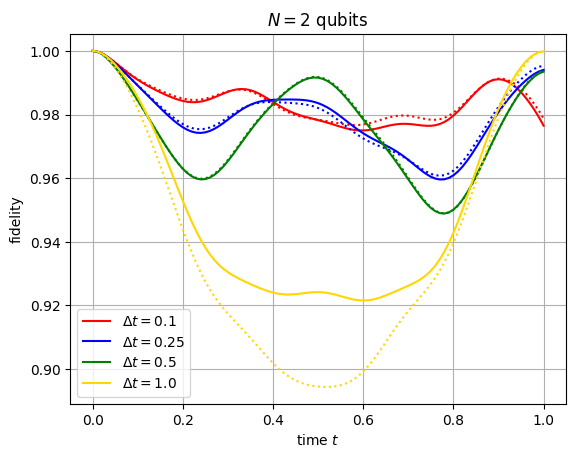

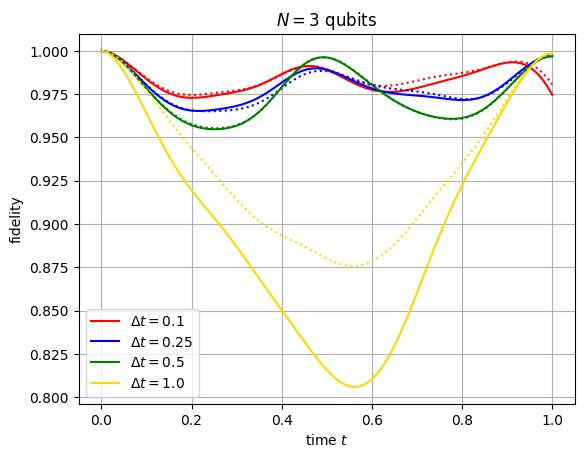

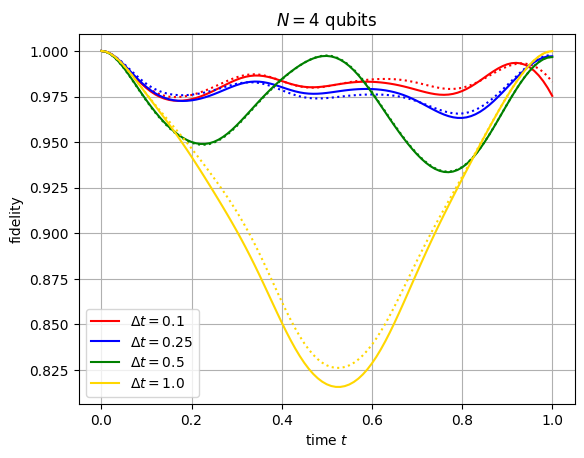

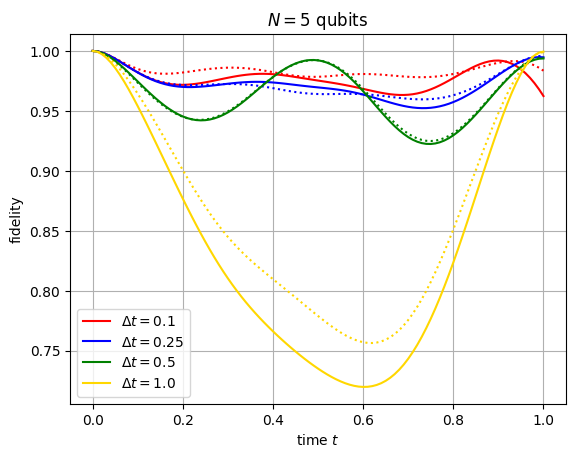

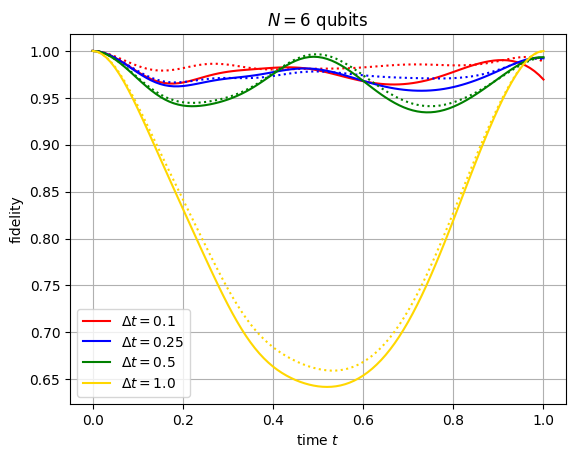

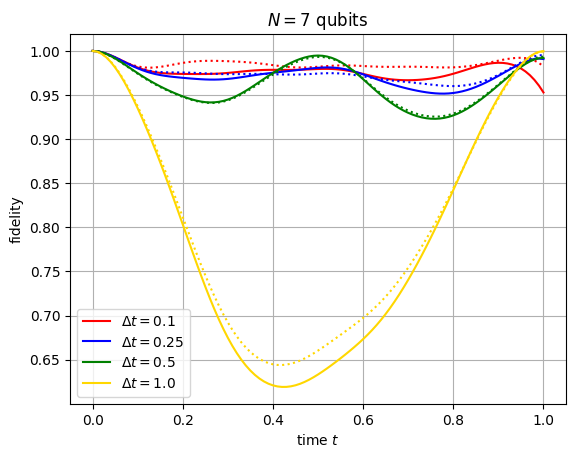

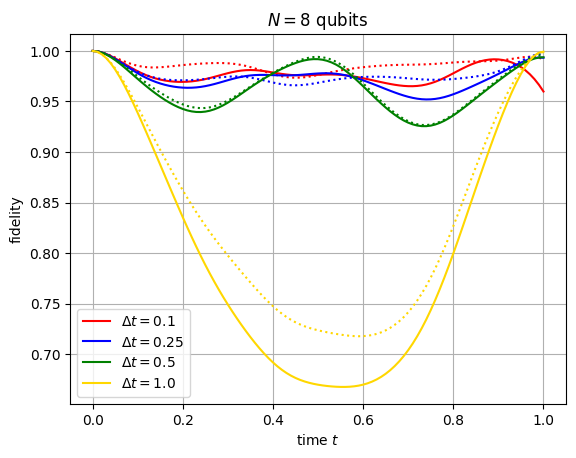

In [6]:
for N in list(set(df_H["N"])):
    for dt, color_dt_ in zip(delta_t, color_dt):
        m1 = f_data(N=N, loss_type='1', delta_t=dt, df=df_H)
        s1 = std_data(N=N, loss_type='1', delta_t=dt, df=df_H)
        m12 = f_data(N=N, loss_type='12', delta_t=dt, df=df_H)
        s12 = std_data(N=N, loss_type='12', delta_t=dt, df=df_H)

        plt.plot(t_test, m1, color=color_dt_, linestyle='-', label=r'$\Delta t = $'+str(dt))
        # plt.fill_between(t_test, m1 - s1, m1 + s1, color=color_dt_, alpha=0.15, linewidth=0)
        plt.plot(t_test, m12, color=color_dt_, linestyle='dotted')
        # plt.fill_between(t_test, m12 - s12, m12 + s12, color=color_dt_, alpha=0.15, linewidth=0)


    plt.grid()
    plt.legend(loc=0)
    # plt.ylim(0.98, 1.005)
    plt.xlabel(r'time $t$')
    plt.ylabel(r'fidelity')
    plt.title(r"$N=$" + str(N) + " qubits")

    plt.show()

In [7]:
print("------------------------ just states ------------------------")
for N in list(set(df_H["N"])):
    print("case N="+str(N))
    for dt in delta_t:
        print(mean_data(N=N, loss_type='1', delta_t=dt, df=df_H))

print("------------------------ states + u's ------------------------")
for N in list(set(df_H["N"])):
    print("case N="+str(N))
    for dt in delta_t:
        print(mean_data(N=N, loss_type='12', delta_t=dt, df=df_H))

------------------------ just states ------------------------
case N=2
(np.float64(0.9838113624270599), np.float64(0.006465243501683228))
(np.float64(0.9791574931380772), np.float64(0.010134576642921798))
(np.float64(0.9749493938861507), np.float64(0.014209910887481888))
(np.float64(0.9494193586972681), np.float64(0.028396602061129615))
case N=3
(np.float64(0.983523979753551), np.float64(0.007096856621277368))
(np.float64(0.9791466335258862), np.float64(0.009482663841409117))
(np.float64(0.9752876555565558), np.float64(0.014264154911979412))
(np.float64(0.9008696886572507), np.float64(0.0629517434737334))
case N=4
(np.float64(0.9825792133217993), np.float64(0.006169978591732451))
(np.float64(0.9786849172988742), np.float64(0.00859038214273775))
(np.float64(0.9692267238503635), np.float64(0.020496733188826267))
(np.float64(0.910860256157299), np.float64(0.06185689892764362))
case N=5
(np.float64(0.977492364562384), np.float64(0.009069032673103952))
(np.float64(0.9722250787338409), np.fl

runs per configuration -- ansatz U: {2: 20, 3: 20, 4: 20, 5: 20, 6: 20}
runs per configuration -- ansatz H_eff: {2: 10, 3: 10, 4: 10, 5: 10, 6: 10, 7: 10, 8: 10}


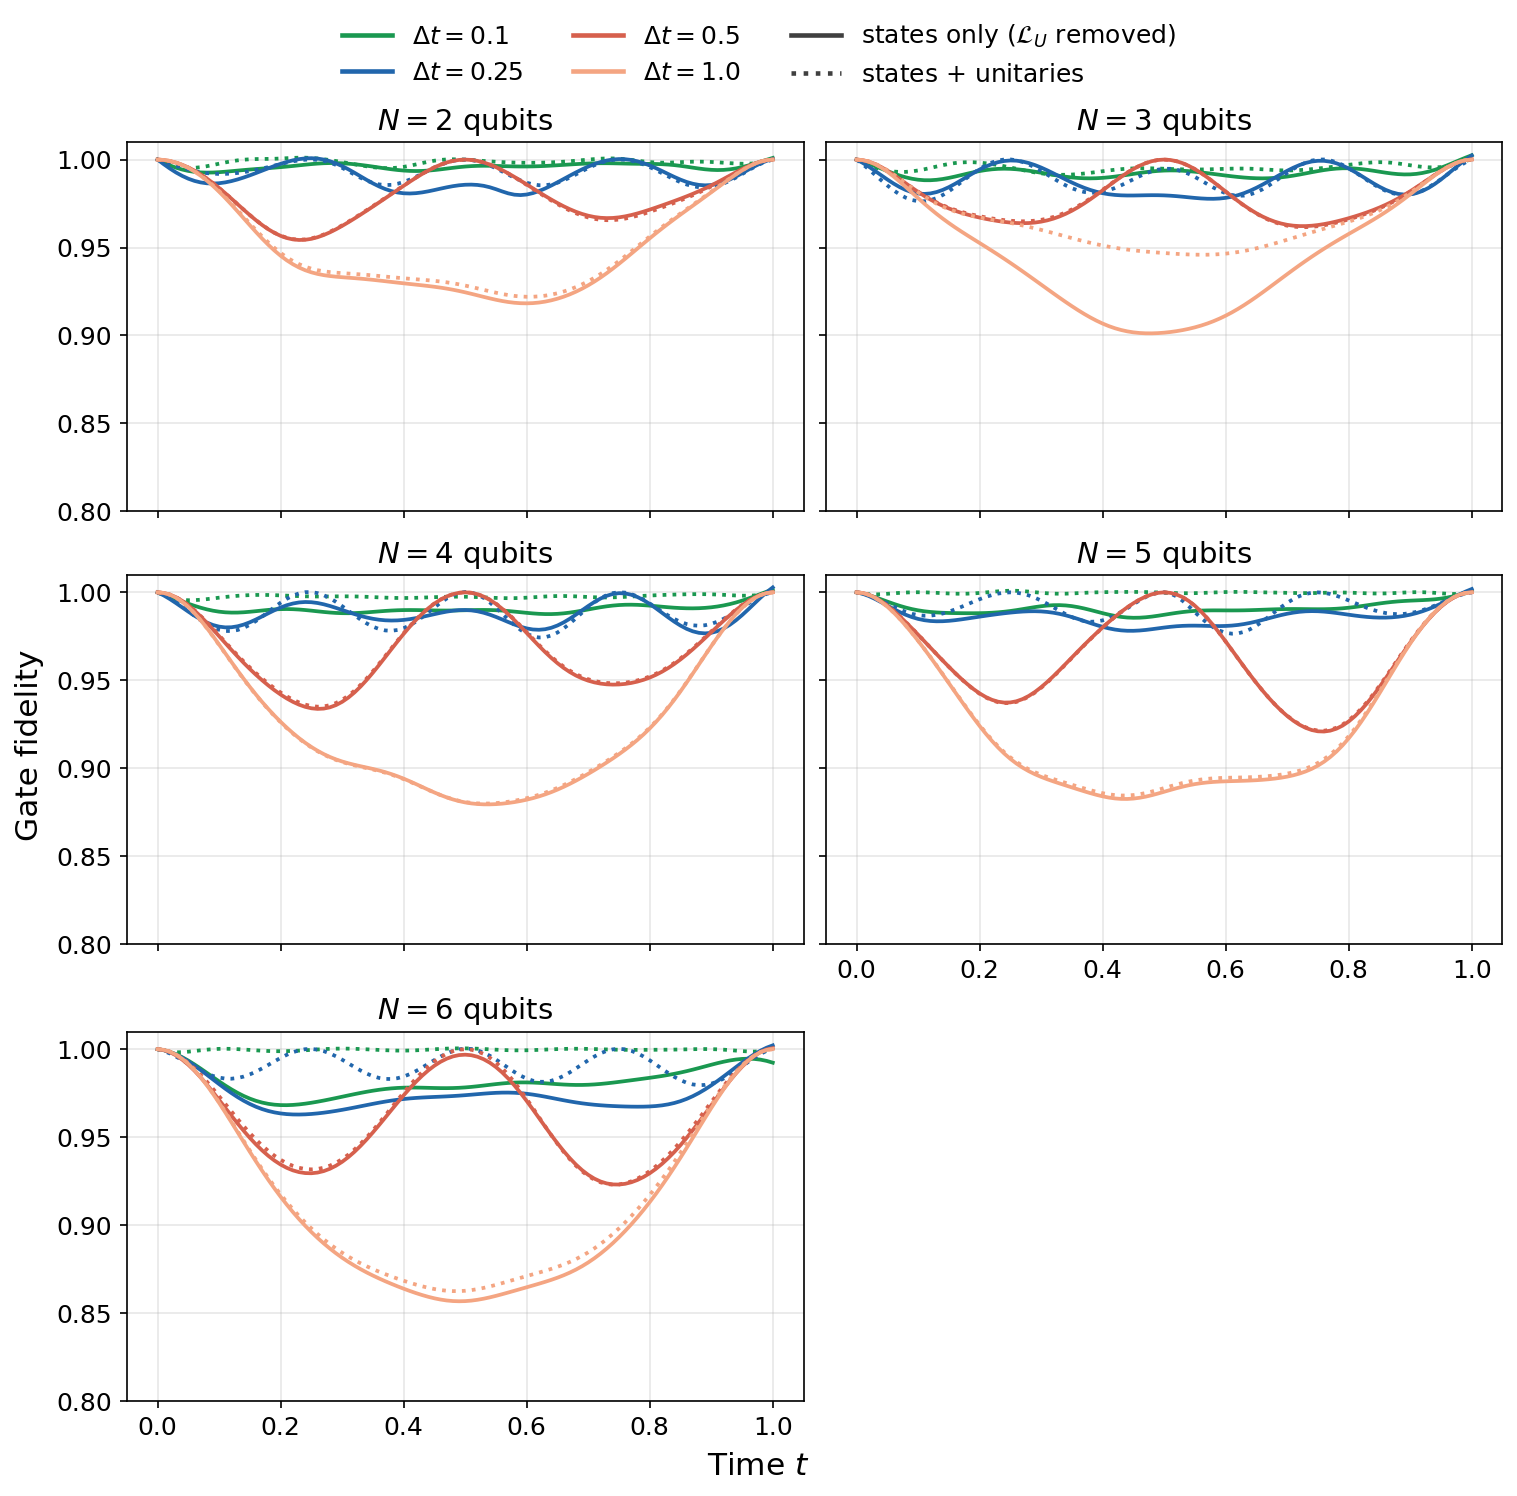

saved: figures/fidelity_loss_ablation_U.pdf


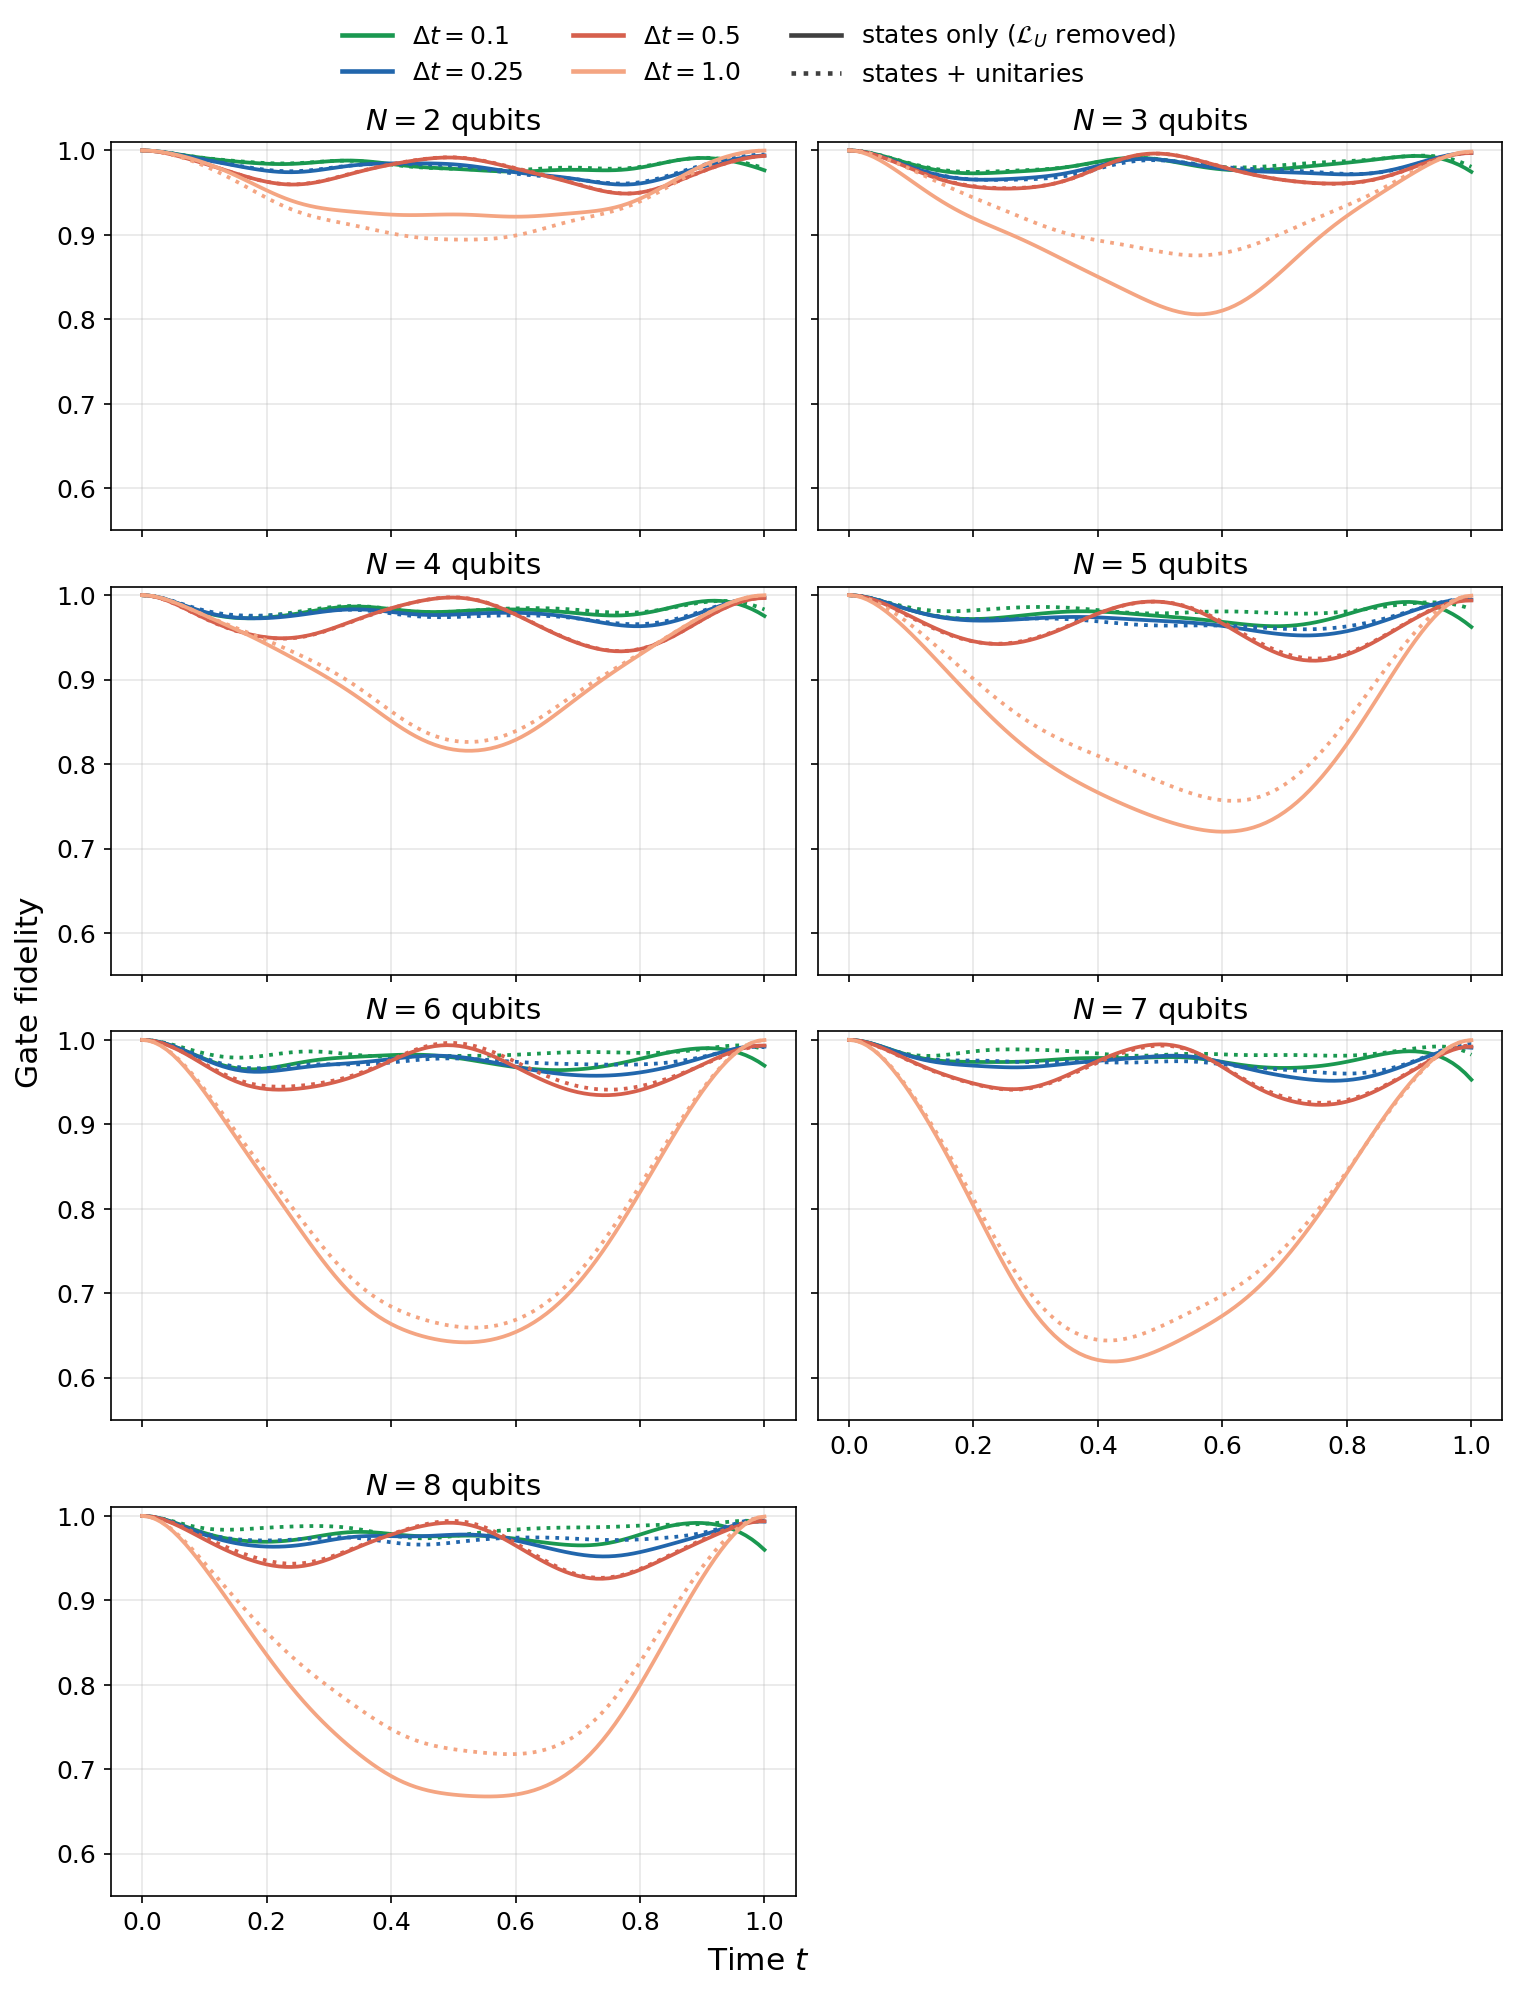

saved: figures/fidelity_loss_ablation_Heff.pdf


In [8]:
from matplotlib.lines import Line2D

colors_dt = {0.10: "#1a9850", 0.25: "#2166ac", 0.50: "#d6604d", 1.00: "#f4a582"}
dt_order = [0.10, 0.25, 0.50, 1.00]


def n_runs(N, df):
    return len(df[(df["N"] == N) & (df["loss_type"] == '1') &
                  (np.round(df['delta_t'], decimals=3) == 0.1)])


def ablation_figure(df, Ns, filename, ncols=2, panel=(5.0, 3.3)):
    nrows = int(np.ceil(len(Ns) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(panel[0] * ncols, panel[1] * nrows),
                             dpi=150, sharex=True, sharey=True, layout='constrained')
    axes = np.atleast_1d(axes).ravel()

    ymin = 1.0
    for ax, N in zip(axes, Ns):
        for dt in dt_order:
            m1 = f_data(N=N, loss_type='1', delta_t=dt, df=df)
            m12 = f_data(N=N, loss_type='12', delta_t=dt, df=df)
            ymin = min(ymin, m1.min(), m12.min())

            ax.plot(t_test, m1, color=colors_dt[dt], linestyle='-', lw=1.8)
            ax.plot(t_test, m12, color=colors_dt[dt], linestyle=':', lw=1.8)

        ax.set_title(rf"$N = {N}$ qubits", fontsize=14)
        ax.tick_params(labelsize=12)
        ax.grid(alpha=0.3)

    axes[0].set_ylim(np.floor((ymin - 0.02) * 20) / 20, 1.01)

    for ax in axes[len(Ns):]:
        ax.remove()

    # With sharex, removing the trailing panels would leave the panel above them
    # without tick labels, so restore them on the last visible axes of each column.
    for col in range(ncols):
        visible = [axes[r * ncols + col] for r in range(nrows)
                   if r * ncols + col < len(Ns)]
        if visible:
            visible[-1].tick_params(labelbottom=True)

    fig.supxlabel(r"Time $t$", fontsize=15)
    fig.supylabel("Gate fidelity", fontsize=15)

    handles = [Line2D([], [], color=colors_dt[dt], lw=2.2,
                      label=rf"$\Delta t = {dt}$") for dt in dt_order]
    handles += [Line2D([], [], color='0.25', lw=2.2, linestyle='-',
                       label=r"states only ($\mathcal{L}_U$ removed)"),
                Line2D([], [], color='0.25', lw=2.2, linestyle=':',
                       label=r"states $+$ unitaries")]
    fig.legend(handles=handles, loc='outside upper center', ncol=3, fontsize=12,
               frameon=False)

    fig.savefig(filename, bbox_inches='tight')
    plt.show()
    print("saved:", filename)


Ns_U = sorted(set(df_U["N"]))
Ns_H = sorted(set(df_H["N"]))
print("runs per configuration -- ansatz U:", {N: n_runs(N, df_U) for N in Ns_U})
print("runs per configuration -- ansatz H_eff:", {N: n_runs(N, df_H) for N in Ns_H})

ablation_figure(df_U, Ns_U, filename="figures/fidelity_loss_ablation_U.pdf")
ablation_figure(df_H, Ns_H, filename="figures/fidelity_loss_ablation_Heff.pdf")